# Assignment 1

## Setup & Imports

In [12]:
# run this cell in case of a problem with the imports 
# %pip install numpy matplotlib pandas scipy seaborn


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


## Part 1: Parameter Analysis Function

In [14]:
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    Parameters:
    -----------
    y : list 
        Populations at time t: [S, I, R, D]
    beta : float
        Transmission rate
    gamma : float
        Recovery rate
    mu : float  
        Mortality rate

    Returns:
    --------
    tuple of floats
        Rates of change (dSdt, dIdt, dRdt, dDdt)
    """
    S, I, R, D = y 
    N = S + I + R + D # Total population

    # Calculation of rates of change
    dSdt = -((S * beta * I) / N)
    dIdt = (S * beta * I) / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt

In [15]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float  
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """

    # Initialization of parameters and plots
    gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]
    summary = []
    plt.figure(figsize=(7, 5))
    
    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]
    time_points = np.linspace(0, simulation_days - 1, simulation_days)

    # Loop over gamma values
    for gamma in gamma_values:
        # Solution of the current system
        sol = odeint(sird_model, y0, time_points, args=(beta, gamma, mu))
        S, I, R, D = sol.T

        # Statistics calculation
        peak_infected = np.max(I)
        peak_day = np.argmax(I)
        # Since death metric is cumulative, we don't need to sum, only take last value
        total_deaths = D[-1]
        # The actual formula for reproduction number for SIRD includes mu
        reproduction_number = beta / (gamma + mu)
        epidemic_duration = np.where(I < 1)[0][0] if np.any(I < 1) else np.nan
        summary.append([gamma, reproduction_number, peak_infected, peak_day, total_deaths,epidemic_duration])

        # Adding new epidemic curve to the plot
        plt.plot(time_points, I, label=f'γ = {gamma} with $R_0$ = {reproduction_number:.2f}', linewidth=2)

    # Formatting the plot
    plt.xlabel('Time (days)')
    plt.ylabel('Infectious Population')
    plt.title('Impact of Recovery Rate (γ) on Infectious Population')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    return pd.DataFrame(summary, columns=['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths','epidemic_duration'])

## Part 2: Scenario Comparison

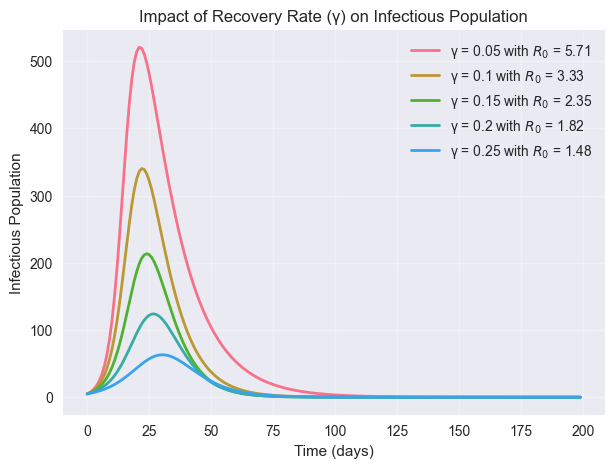

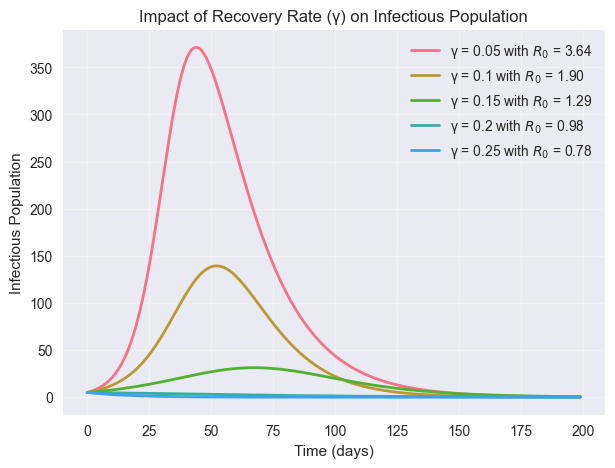

In [16]:
# Scenario A = "High Tranmission"
results_high = analyze_recovery_rates(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200)
# Scenario B = "Low Transmission"
results_low= analyze_recovery_rates(beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200)

# both plots are displayed below 

In [17]:
from IPython.display import display

display(results_high)
display(results_low)

,gamma,R0,peak_infected,peak_day,total_deaths,epidemic_duration
0,0.05,5.714286,520.582635,21,284.757361,118
1,0.10,3.333333,340.140583,22,159.892366,86
2,0.15,2.352941,213.465894,24,102.610885,77
3,0.20,1.818182,123.893909,27,67.423926,78
4,0.25,1.481481,63.051893,30,42.694003,84


,gamma,R0,peak_infected,peak_day,total_deaths,epidemic_duration
0,0.05,3.636364,371.356334,44,88.224137,178
1,0.10,1.904762,139.333450,52,36.699911,154
2,0.15,1.290323,31.340756,67,13.640017,185
3,0.20,0.975610,5.000000,0,1.831032,116
4,0.25,0.784314,5.000000,0,0.433166,28


### **Analysis of Both Scenarios and Scenario comparison**

**Scenario One: High Transmission**

Scenario One represents the **high transmission case**, which is determined by a beta value of **0.4** and a mortality rate of **0.02**. For all of the gamma values, the $R_0$ rate is greater than one, which represents an epidemic. We can also notice a **negative correlation** between the gamma values and $R_0$ - the higher the gamma value, the lower the $R_0$ rate. This realistically makes sense since the higher the gamma value, the more people recover per day. The next thing to notice is the `peak_infected` parameter, which also goes down as gamma increases. An interesting observation is that the `peak_day` shows a **positive trend** with the gamma value. This means that with higher recovery rates, the epidemic reaches its peak later. Finally, `total_deaths` shows a similar decreasing trend to $R_0$ and `peak_infected`. This is logical because as the recovery rate increases, fewer people become infected and more infected recover rather than die.

**Scenario Two: Low Transmission**

In Scenario Two, we can notice a similar pattern between the **gamma rate**, $R_0$, and `peak_infected`. As the gamma rate increases, both $R_0$ and `peak_infected` decrease. However, in this case, we notice some rows with an $R_0$ lower than one, which represents a **decline in the spread of the infection**. For these cases, the peak of infected occurs on **day zero**, meaning that the number of infected  starts decreasing immediately. This differs from what we observed in Scenario One, where the infection initially grows and reaches its peak later.

**Conclusions**

After observing both tables, we can clearly see that **Scenario One is worse for public health**. In all of the cases, we notice a higher spread of the disease, represented by the higher $R_0$ values, which leads to more infected people. The mortality rate is also higher, resulting in a **higher number of total deaths** compared to Scenario Two.





## Part 3: Policy Recommendations

### **3.1 Parameter impact analysis**

Increasing the recovery rate (`gamma`) has a strong effect on the severity of the epidemic. Using data from Scenario A:

As `gamma` increases from 0.05 to 0.25, the peak number of infected individuals decreases from approximately **520.6 to 63.1**, corresponding to a reduction of about **87.9%**. At the same time, the peak occurs later, shifting from day **21** to day **30**. This indicates that faster recovery reduces and flattens the infection peak.

Total deaths also decrease substantially as the recovery rate increases. At `gamma = 0.05`, the model predicts approximately **284.8 deaths**, whereas at `gamma = 0.25` this decreases to approximately **42.7 deaths**, a reduction of about **85.0%**.

The effect on epidemic duration is less straightforward. Increasing `gamma` initially shortens the epidemic considerably: the duration decreases from **118 days** at `gamma = 0.05` to a minimum of **77 days** at `gamma = 0.15`. However, further increases in recovery rate do not continue to reduce the duration. The epidemic lasts **78 days** at `gamma = 0.20` and **84 days** at `gamma = 0.25`.

Therefore, increasing the recovery rate consistently reduces the infection peak and total deaths, but its effect on epidemic duration is **non-monotonic**. In these simulations, intermediate recovery rates produced the shortest epidemic, while the highest recovery rate produced a much smaller and less severe epidemic but not the shortest one.


### **3.2 Intervention analysis**

For this analysis, the Scenario A result with a recovery rate of $\gamma=0.10$ is used as the baseline. An intervention that increases the recovery rate by 50% would produce a new recovery rate of:

$$
\gamma_{\text{intervention}} = 0.10 \times 1.50 = 0.15
$$

At the baseline recovery rate of $\gamma=0.10$, the model predicts approximately 159.89 total deaths. At the increased recovery rate of $\gamma=0.15$, the predicted number of deaths decreases to approximately 102.61.

Therefore, the expected number of deaths prevented is:

$$
159.89 - 102.61 = 57.28
$$

The relative reduction in mortality is:

$$
\frac{57.28}{159.89} \times 100 \approx 35.83%
$$

So an intervention capable of increasing the recovery rate by **50% would therefore reduce total deaths by approximately 35.8%**, preventing about **57 deaths per 1,000 individuals** in Scenario A.

The reduction in deaths is smaller than 50% due to the relationship between recovery rate and mortality being non-linear.

### **3.3 Real-world application**

One medical intervention capable of increasing recovery rate is **antibiotic treatment** of a bacterial infectious disease. Antibiotics either inhibit bacterial replication or kill the pathogen directly, reducing pathogen load and allowing infected individuals to recover more rapidly.

In order to estimate real effectiveness we will use real observational data from test trial in uncomplicated urinary tract infection (https://pubmed.ncbi.nlm.nih.gov/36376070/).

Based on the reports: \
    -  **With antibiotics:** Symptoms for common mild-to-moderate bacterial infections often improve within 7 days. \
    -  **Without antibiotics:** Many patients still recover on their own, though self-reported recovery can take roughly 2 days longer.

Therefore, **taking antibiotics** for conditions like uncomplicated urinary tract infections **reduces the median recovery time by about 2 days** (7 days with antibiotics versus 9 days without).

# Conclusions

This assignment provided us with key insights into Epidemiological Modelling and how different model parameters influence the development and severity of an epidemic.

After implementing the `sird_model` and `analyze_recovery_rates` functions, we investigated two different scenarios: **Scenario A - High Transmission** and **Scenario B - Low Transmission**. The scenarios used different transmission (`beta`) and mortality (`mu`) rates, while we tested several values of the recovery rate (`gamma`). From the comparison, we concluded that **Scenario A is worse for public health**. Across the tested recovery rates, it resulted in a greater spread of the disease, higher peaks in the infected population, and a higher number of total deaths compared to Scenario B.

In the policy analysis, we investigated the effect of changing the recovery rate. The results reinforced our previous observations: **increasing `gamma` generally has a positive effect on the epidemic outcome**, as it lowers the peak number of infected individuals and substantially reduces total deaths. However, its effect on epidemic duration was not as straightforward, since the shortest epidemic did not occur at the highest recovery rate.

We then explored a possible intervention that increased the recovery rate by 50%. In Scenario A, increasing `gamma` from 0.10 to 0.15 reduced the predicted deaths from approximately 159.89 to 102.61, corresponding to about **57 prevented deaths per 1,000 individuals** and a **35.8% reduction in mortality**.

Finally, we explored a real-world application with antibiotic treatment for bacterial infections as an intervention. This example showed us how an intervention that shortens recovery time(from 9 to 7 days, as shown above) can be represented through an increased recovery rate in the SIRD model. 

Overall, we found the assignment really interesting and it showed us how we can apply mathematical modelling not only to describe the development of an epidemic, but also to compare scenarios and estimate the possible impact of public-health interventions.
